In [1]:
import math
import os
import pickle
import sys

import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

matplotlib.rcParams['text.usetex'] = False

sys.path.insert(0, '..')
from plot_config import MODEL_COLORS, MODEL_DISPLAY_NAMES, MODEL_MARKERS, FONT_SIZES

plt.rcParams.update(FONT_SIZES)

In [2]:
project_root = "../../../.."

# Toggle: set True to load pre-computed results from disk (fast), False to run full data processing
LOAD_PROCESSED_DATA = True

_script_name = "codon_level_read_length"
_cache_dir = f"{project_root}/data/processed_data/report_results/without_errors/{_script_name}"

all_test_accessions = open(f"{project_root}/data/processed_data/genome_partitions/test_partition_accessions.txt").read().splitlines()

# Load genome info from CSV and create dict for all test accessions
genome_info_df = pd.read_csv(f"{project_root}/data/processed_data/dataset_information/genomes_info_with_partitions.csv")
genome_info_df = genome_info_df.set_index('accession')

# Families that use translation table 4 (Mycoplasmataceae and related)
tt4_families = ['Mycoplasmataceae']

all_genomes = {}
for acc in all_test_accessions:
    if acc in genome_info_df.index:
        row = genome_info_df.loc[acc]
        translation_table = 4 if row['family'] in tt4_families else 11
        all_genomes[acc] = {
            'family': row['family'],
            'domain': row['domain'],
            'gc_content': row['gc_content'],
            'translation_table': translation_table
        }

print(f"Total test accessions: {len(all_test_accessions)}")

read_lengths = [75, 100, 150, 300, 700, 1000]
model_names = ["fgs_complete", "prodigal", "deep_cds"]
models_per_length = {l: model_names for l in read_lengths}

Total test accessions: 215


In [3]:
def calculate_rates_for_rf(cds_rf_testset, cds_rf_preds, codons_per_rf):
    """Compute codon-level TP/FP/FN/TN for a single reading frame.

    Uses a boolean coverage array of length codons_per_rf * 3 (truncated to
    the nearest multiple of 3 to ensure clean codon counting). Coordinates
    are 1-based and assumed to already be shifted to reading frame 0.

    Args:
        cds_rf_testset: List of (start, end) tuples for ground-truth CDS in this RF.
        cds_rf_preds: List of (start, end) tuples for predicted CDS in this RF.
        codons_per_rf: Number of codons in this reading frame.
        seq_len: Original read length (used only to derive array length).

    Returns:
        Tuple of (TP, FP, FN, TN) codon counts.
    """
    seq_len_pred = codons_per_rf * 3  # truncate to nearest multiple of 3
    pred_covered = np.zeros(seq_len_pred, dtype=bool)
    actual_covered = np.zeros(seq_len_pred, dtype=bool)

    for start, end in cds_rf_preds:
        pred_covered[start - 1:end] = True

    for start, end in cds_rf_testset:
        actual_covered[start - 1:end] = True

    TP = int(np.sum(pred_covered & actual_covered) / 3)
    FP = int(np.sum(pred_covered & ~actual_covered) / 3)
    FN = int(np.sum(~pred_covered & actual_covered) / 3)
    TN = int(np.sum(~pred_covered & ~actual_covered) / 3)

    assert TP + FP + FN + TN == codons_per_rf

    return TP, FP, FN, TN


def matthews_corrcoef(TP, FP, FN, TN):
    """Compute Matthews Correlation Coefficient (MCC).

    Args:
        TP, FP, FN, TN: Confusion matrix counts.

    Returns:
        MCC in range [-1, 1]. Returns 0.0 if the denominator is zero.
    """
    numerator = (TP * TN) - (FP * FN)
    denominator = math.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    return numerator / denominator if denominator != 0 else 0.0


def calculate_performance_metrics_model(testset_dict, model_preds_dict, read_names_list,
                                        codons_per_rf, codons_total, seq_len):
    """Codon-level evaluation across all reads for a single model.

    For each read, splits CDS coordinates by reading frame (0, 1, 2), shifting
    rf1 by -1 and rf2 by -2 to normalise to frame 0 coordinates, then calls
    calculate_rates_for_rf per frame. 'disrupted_rf' entries are silently skipped.

    Args:
        testset_dict: Ground-truth annotations dict.
        model_preds_dict: Model predictions dict.
        read_names_list: List of all read names to evaluate.
        codons_per_rf: Number of codons per reading frame (= (seq_len-3)//3).
        codons_total: Total codons across all 3 RFs (= codons_per_rf * 3).
        seq_len: Read length in bp.

    Returns:
        Dict with keys 'tp', 'fp', 'fn', 'tn', 'mcc', 'f1_score', 'precision', 'recall'.
    """
    TP = FP = FN = TN = 0

    for read in read_names_list:
        in_test = read in testset_dict
        in_pred = read in model_preds_dict

        if not in_test and not in_pred:
            # Non-coding read, no prediction: all TN
            TN += codons_total

        elif in_test and not in_pred:
            # Has CDS, nothing predicted: FN + TN
            cds_rf0_test = [(c[0], c[1]) for c in testset_dict[read]['cds_coords'] if c[2] == '0']
            cds_rf1_test = [(c[0] - 1, c[1] - 1) for c in testset_dict[read]['cds_coords'] if c[2] == '1']
            cds_rf2_test = [(c[0] - 2, c[1] - 2) for c in testset_dict[read]['cds_coords'] if c[2] == '2']
            for rf_test in [cds_rf0_test, cds_rf1_test, cds_rf2_test]:
                tp_, fp_, fn_, tn_ = calculate_rates_for_rf(rf_test, [], codons_per_rf)
                TP += tp_; FP += fp_; FN += fn_; TN += tn_

        elif not in_test and in_pred:
            # Non-coding read, something predicted: FP + TN
            cds_rf0_pred = [(c[0], c[1]) for c in model_preds_dict[read]['cds_coords'] if c[2] == '0']
            cds_rf1_pred = [(c[0] - 1, c[1] - 1) for c in model_preds_dict[read]['cds_coords'] if c[2] == '1']
            cds_rf2_pred = [(c[0] - 2, c[1] - 2) for c in model_preds_dict[read]['cds_coords'] if c[2] == '2']
            for rf_pred in [cds_rf0_pred, cds_rf1_pred, cds_rf2_pred]:
                tp_, fp_, fn_, tn_ = calculate_rates_for_rf([], rf_pred, codons_per_rf)
                TP += tp_; FP += fp_; FN += fn_; TN += tn_

        else:
            # Both have CDS: full RF-split evaluation
            cds_rf0_test = [(c[0], c[1]) for c in testset_dict[read]['cds_coords'] if c[2] == '0']
            cds_rf1_test = [(c[0] - 1, c[1] - 1) for c in testset_dict[read]['cds_coords'] if c[2] == '1']
            cds_rf2_test = [(c[0] - 2, c[1] - 2) for c in testset_dict[read]['cds_coords'] if c[2] == '2']
            cds_rf0_pred = [(c[0], c[1]) for c in model_preds_dict[read]['cds_coords'] if c[2] == '0']
            cds_rf1_pred = [(c[0] - 1, c[1] - 1) for c in model_preds_dict[read]['cds_coords'] if c[2] == '1']
            cds_rf2_pred = [(c[0] - 2, c[1] - 2) for c in model_preds_dict[read]['cds_coords'] if c[2] == '2']
            for rf_test, rf_pred in [(cds_rf0_test, cds_rf0_pred),
                                     (cds_rf1_test, cds_rf1_pred),
                                     (cds_rf2_test, cds_rf2_pred)]:
                tp_, fp_, fn_, tn_ = calculate_rates_for_rf(rf_test, rf_pred, codons_per_rf)
                TP += tp_; FP += fp_; FN += fn_; TN += tn_

    mcc = matthews_corrcoef(TP, FP, FN, TN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        'tp': TP, 'fp': FP, 'fn': FN, 'tn': TN,
        'mcc': round(mcc, 4), 'f1_score': round(f1, 4),
        'precision': round(precision, 4), 'recall': round(recall, 4)
    }

In [6]:
def load_testset(test_accession, data_type, project_root=project_root):
    with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/testset_dict.pkl", "rb") as f:
        testset_dict = pickle.load(f)
    with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/read_names_list.pkl", "rb") as f:
        read_names_list = pickle.load(f)
    return read_names_list, testset_dict


def load_model_preds(test_accession, data_type, model_name, project_root=project_root):
    pred_paths = {
        "prodigal": f"{project_root}/data/processed_data/predictions/processed_predictions/prodigal_preds/{data_type}/{test_accession}/model_preds_dict.pkl",
        "fgs_complete": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{data_type}/{test_accession}.pkl",
        "deep_cds": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_without_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/model_preds_dict.pkl",
    }
    with open(pred_paths[model_name], "rb") as f:
        preds = pickle.load(f)
    return preds

# Evaluate performance across read lengths (codon-level)

In [8]:
# GC-content bins
gc_bins = [0, 40, 50, 60, 100]
gc_bin_labels = [r"$<$40\%", r"40--50\%", r"50--60\%", r"$>$60\%"]

def get_gc_bin_label(gc_content):
    """Return the GC-content bin label for a given GC percentage value."""
    for i in range(len(gc_bins) - 1):
        if gc_bins[i] <= gc_content < gc_bins[i + 1]:
            return gc_bin_labels[i]
    return None

def _init_length_gc_dict():
    """Initialize a nested dict of {read_length: {gc_label: {model: counts}}}."""
    return {
        length: {gc_label: {model: {'tp': 0, 'fp': 0, 'fn': 0, 'tn': 0} for model in model_names}
                 for gc_label in gc_bin_labels}
        for length in read_lengths
    }

def _init_has_data_dict():
    """Initialize a nested dict of {read_length: {model: bool}} tracking data availability."""
    return {length: {model: False for model in model_names} for length in read_lengths}

if not LOAD_PROCESSED_DATA:
    # Overall (excludes TT4 genomes for fair comparison)
    results_by_length = {
        length: {model: {'tp': 0, 'fp': 0, 'fn': 0, 'tn': 0} for model in model_names}
        for length in read_lengths
    }
    results_by_length_gc = _init_length_gc_dict()
    has_data = _init_has_data_dict()

    # Per translation table
    results_by_length_gc_tt11 = _init_length_gc_dict()
    results_by_length_gc_tt4 = _init_length_gc_dict()
    has_data_tt11 = _init_has_data_dict()
    has_data_tt4 = _init_has_data_dict()

    # Per-genome metric lists for min/max error bars (excludes TT4)
    per_genome_metrics_list = {
        length: {model: {'mcc': [], 'f1_score': [], 'precision': [], 'recall': []}
                 for model in model_names}
        for length in read_lengths
    }

    for length in read_lengths:
        data_type = f"without_errors_{length}bp"
        seq_len = length
        codons_per_rf = (seq_len - 3) // 3
        codons_total = codons_per_rf * 3
        available_models = models_per_length[length]
        print(f"\nProcessing {data_type} (codons_per_rf={codons_per_rf}, codons_total={codons_total})...")

        for test_accession in tqdm(all_test_accessions, desc=f"{length}bp"):
            try:
                read_names_list, testset_dict = load_testset(test_accession, data_type)
            except Exception as e:
                print(f"Error loading testset for {test_accession} at {length}bp: {e}")
                continue

            # Determine GC bin and translation table for this accession
            gc_label = None
            tt = None
            if test_accession in all_genomes:
                gc_label = get_gc_bin_label(all_genomes[test_accession]['gc_content'])
                tt = all_genomes[test_accession]['translation_table']

            for model in available_models:
                try:
                    preds = load_model_preds(test_accession, data_type, model)
                    metrics = calculate_performance_metrics_model(
                        testset_dict, preds, read_names_list, codons_per_rf, codons_total, seq_len)
                    tp = metrics['tp']
                    fp = metrics['fp']
                    fn = metrics['fn']
                    tn = metrics['tn']

                    # Overall aggregation (exclude TT4 for fair comparison)
                    if tt != 4:
                        results_by_length[length][model]['tp'] += tp
                        results_by_length[length][model]['fp'] += fp
                        results_by_length[length][model]['fn'] += fn
                        results_by_length[length][model]['tn'] += tn
                        has_data[length][model] = True

                        per_genome_metrics_list[length][model]['mcc'].append(metrics['mcc'])
                        per_genome_metrics_list[length][model]['f1_score'].append(metrics['f1_score'])
                        per_genome_metrics_list[length][model]['precision'].append(metrics['precision'])
                        per_genome_metrics_list[length][model]['recall'].append(metrics['recall'])

                        if gc_label is not None:
                            results_by_length_gc[length][gc_label][model]['tp'] += tp
                            results_by_length_gc[length][gc_label][model]['fp'] += fp
                            results_by_length_gc[length][gc_label][model]['fn'] += fn
                            results_by_length_gc[length][gc_label][model]['tn'] += tn

                    # Per-TT aggregation
                    if gc_label is not None:
                        if tt == 11:
                            results_by_length_gc_tt11[length][gc_label][model]['tp'] += tp
                            results_by_length_gc_tt11[length][gc_label][model]['fp'] += fp
                            results_by_length_gc_tt11[length][gc_label][model]['fn'] += fn
                            results_by_length_gc_tt11[length][gc_label][model]['tn'] += tn
                            has_data_tt11[length][model] = True
                        elif tt == 4:
                            results_by_length_gc_tt4[length][gc_label][model]['tp'] += tp
                            results_by_length_gc_tt4[length][gc_label][model]['fp'] += fp
                            results_by_length_gc_tt4[length][gc_label][model]['fn'] += fn
                            results_by_length_gc_tt4[length][gc_label][model]['tn'] += tn
                            has_data_tt4[length][model] = True
                except Exception as e:
                    print(f"Error loading {model} for {test_accession} at {length}bp: {e}")
                    continue

    print("\nDone.")

else:
    print(f"Loading pre-computed results from:\n  {_cache_dir}")
    with open(os.path.join(_cache_dir, "results_by_length.pkl"), "rb") as f:
        results_by_length = pickle.load(f)
    with open(os.path.join(_cache_dir, "results_by_length_gc.pkl"), "rb") as f:
        results_by_length_gc = pickle.load(f)
    with open(os.path.join(_cache_dir, "has_data.pkl"), "rb") as f:
        has_data = pickle.load(f)
    with open(os.path.join(_cache_dir, "results_by_length_gc_tt11.pkl"), "rb") as f:
        results_by_length_gc_tt11 = pickle.load(f)
    with open(os.path.join(_cache_dir, "results_by_length_gc_tt4.pkl"), "rb") as f:
        results_by_length_gc_tt4 = pickle.load(f)
    with open(os.path.join(_cache_dir, "has_data_tt11.pkl"), "rb") as f:
        has_data_tt11 = pickle.load(f)
    with open(os.path.join(_cache_dir, "has_data_tt4.pkl"), "rb") as f:
        has_data_tt4 = pickle.load(f)
    with open(os.path.join(_cache_dir, "per_genome_metrics_list.pkl"), "rb") as f:
        per_genome_metrics_list = pickle.load(f)

Loading pre-computed results from:
  ../../../../data/processed_data/report_results/without_errors/codon_level_read_length


In [9]:
if not LOAD_PROCESSED_DATA:
    os.makedirs(_cache_dir, exist_ok=True)
    _objects_to_save = {
        "results_by_length": results_by_length,
        "results_by_length_gc": results_by_length_gc,
        "has_data": has_data,
        "results_by_length_gc_tt11": results_by_length_gc_tt11,
        "results_by_length_gc_tt4": results_by_length_gc_tt4,
        "has_data_tt11": has_data_tt11,
        "has_data_tt4": has_data_tt4,
        "per_genome_metrics_list": per_genome_metrics_list,
    }
    for name, obj in _objects_to_save.items():
        with open(os.path.join(_cache_dir, f"{name}.pkl"), "wb") as f:
            pickle.dump(obj, f)
    print(f"Results saved to {_cache_dir}")

In [10]:
# Compute aggregated metrics from raw counts
metrics_keys = ['mcc', 'f1_score', 'precision', 'recall']
aggregated_metrics = {model: {k: [] for k in metrics_keys} for model in model_names}

for length in read_lengths:
    for model in model_names:
        if not has_data[length][model]:
            for k in metrics_keys:
                aggregated_metrics[model][k].append(np.nan)
            continue

        tp = results_by_length[length][model]['tp']
        fp = results_by_length[length][model]['fp']
        fn = results_by_length[length][model]['fn']
        tn = results_by_length[length][model]['tn']

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        mcc = matthews_corrcoef(tp, fp, fn, tn)

        aggregated_metrics[model]['mcc'].append(mcc)
        aggregated_metrics[model]['f1_score'].append(f1)
        aggregated_metrics[model]['precision'].append(precision)
        aggregated_metrics[model]['recall'].append(recall)

# Compute per-genome min/max for error bars
per_genome_min_max = {
    model: {metric: {'min': [], 'max': []} for metric in metrics_keys}
    for model in model_names
}


# Plot performance as a function of read length

In [16]:
model_display_names = MODEL_DISPLAY_NAMES
model_colors = MODEL_COLORS
model_markers = MODEL_MARKERS

def plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, metric_name, ylabel):
    """Plot per-genome metric distributions as grouped boxplots across read lengths.

    Args:
        per_genome_metrics_list: Dict of {length: {model: {metric_name: [values_per_genome]}}}.
        read_lengths: List of read lengths for the x-axis.
        metric_name: Key into metrics (e.g. 'f1_score', 'mcc', 'precision', 'recall').
        ylabel: Y-axis label and part of the plot title.
    """
    matplotlib.rcParams['text.usetex'] = False

    active_models = [m for m in model_names
                     if any(per_genome_metrics_list[l][m][metric_name] for l in read_lengths)]
    if not active_models:
        print("No data available.")
        return

    n_active = len(active_models)
    fig, ax = plt.subplots(figsize=(11, 7))

    x_positions = np.arange(len(read_lengths))
    box_width = 0.8 / n_active
    offsets = (np.arange(n_active) - (n_active - 1) / 2) * box_width

    for k, model in enumerate(active_models):
        color = model_colors[model]
        positions, data = [], []
        for i, length in enumerate(read_lengths):
            vals = per_genome_metrics_list[length][model][metric_name]
            if vals:
                positions.append(x_positions[i] + offsets[k])
                data.append(vals)
        if not data:
            continue

        bp = ax.boxplot(
            data,
            patch_artist=True,
            positions=positions,
            widths=box_width * 0.9,
            showfliers=True,
            flierprops=dict(marker='o', markersize=3, alpha=0.5,
                            markerfacecolor=color, markeredgecolor=color),
            manage_ticks=False,
        )
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        for line in bp['medians']:
            line.set_color('black')
            line.set_linewidth(1.5)
        ax.plot([], [], color=color, linewidth=6, alpha=0.7,
                label=model_display_names[model])

    ax.set_xlabel('Read Length (bp)')
    ax.set_ylabel(ylabel)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([str(l) for l in read_lengths])
    ax.set_ylim(0.3, 1.01)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=4)

    plt.tight_layout()
    # plt.savefig(f"codon_level_metrics_by_read_length_boxplot_{metric_name}.svg", dpi=500, bbox_inches='tight')
    plt.show()

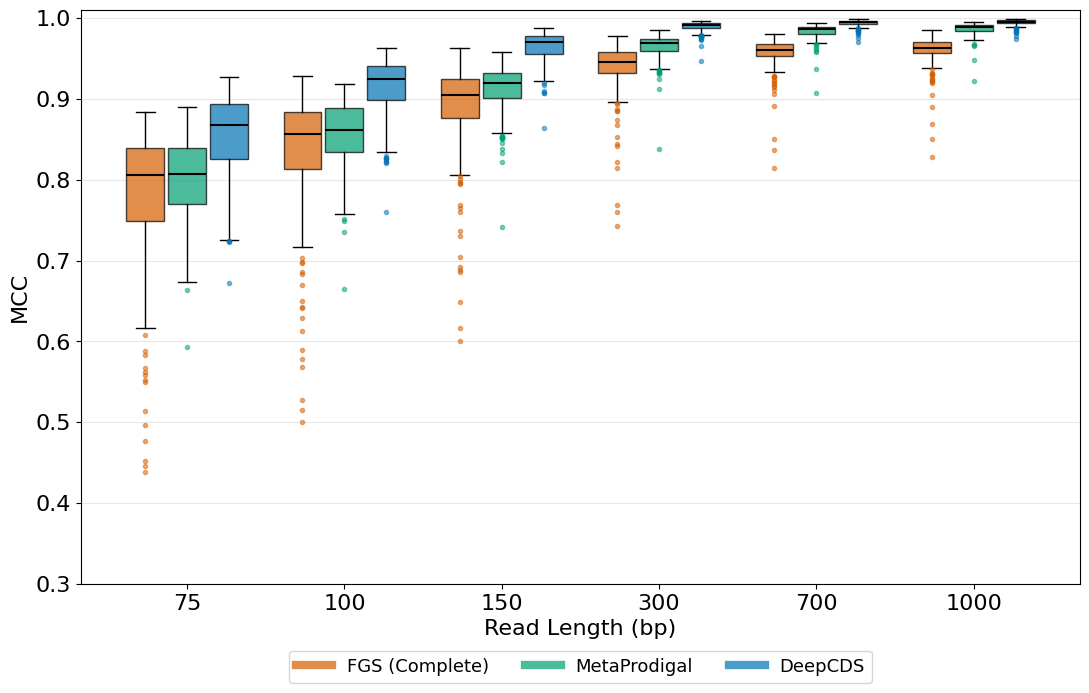

In [17]:
#plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, 'f1_score', 'F1 Score')
plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, 'mcc', 'MCC')
#plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, 'precision', 'Precision')
#plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, 'recall', 'Sensitivity')

In [18]:
# Generate LaTeX table with 4 metric sections (MCC, F1, Sensitivity, Precision)
# Rows: model names grouped by metric; Columns: read lengths
# Best score per read length is bolded

metrics_order = [
    ('mcc',       'MCC'),
    #('f1_score',  'F1 Score'),
    #('recall',    'Sensitivity'),
    #('precision', 'Precision'),
]

col_fmt = 'l' + 'c' * len(read_lengths)
header_cols = ' & '.join([f'{l}bp' for l in read_lengths])

lines = []
lines.append(r'\begin{table}[ht]')
lines.append(r'\centering')
lines.append(rf'\begin{{tabular}}{{{col_fmt}}}')
lines.append(r'\toprule')
lines.append(f' & {header_cols} \\\\')

for sec_idx, (metric_key, metric_label) in enumerate(metrics_order):
    lines.append(r'\midrule')
    lines.append(rf'\multicolumn{{{1 + len(read_lengths)}}}{{l}}{{\textbf{{{metric_label}}}}} \\')
    lines.append(r'\midrule')

    # Find best value per read length for this metric
    best_per_length = []
    for i in range(len(read_lengths)):
        col_vals = [aggregated_metrics[model][metric_key][i] for model in model_names]
        valid = [v for v in col_vals if not np.isnan(v)]
        best_per_length.append(max(valid) if valid else None)

    for model in model_names:
        display = model_display_names[model]
        vals = []
        for i, length in enumerate(read_lengths):
            v = aggregated_metrics[model][metric_key][i]
            if np.isnan(v):
                vals.append('--')
            elif best_per_length[i] is not None and v == best_per_length[i]:
                vals.append(rf'\textbf{{{v:.3f}}}')
            else:
                vals.append(f'{v:.3f}')
        row = f'{display} & ' + ' & '.join(vals) + r' \\'
        lines.append(row)

lines.append(r'\bottomrule')
lines.append(r'\end{tabular}')
lines.append(r'\caption{TODO: WRITE CAPTION.}')
lines.append(r'\label{tab:codon_read_length_no_errors}')
lines.append(r'\end{table}')

print('\n'.join(lines))

\begin{table}[ht]
\centering
\begin{tabular}{lcccccc}
\toprule
 & 75bp & 100bp & 150bp & 300bp & 700bp & 1000bp \\
\midrule
\multicolumn{7}{l}{\textbf{MCC}} \\
\midrule
FGS (Complete) & 0.796 & 0.847 & 0.897 & 0.942 & 0.959 & 0.961 \\
MetaProdigal & 0.801 & 0.856 & 0.913 & 0.965 & 0.984 & 0.987 \\
DeepCDS & \textbf{0.864} & \textbf{0.921} & \textbf{0.967} & \textbf{0.990} & \textbf{0.994} & \textbf{0.995} \\
\bottomrule
\end{tabular}
\caption{TODO: WRITE CAPTION.}
\label{tab:codon_read_length_no_errors}
\end{table}
